Linear Regression


Linear Regression is one of the basic and widely used algorithms in Machine Learning and Statistics. It is a learning algorithm that predicts a continuous target variable based on one or more input features.


1. Imports

* **Numpy** is used for math operations and handling arrays.

* **pandas** is used for data manipulation and analysis.

* **matplotlib** and **seaborn** are used for data visualization.

* **sklearn** is the library for machine learning in Python. We import modules to split our data build the model and measure performance.



In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# from sklearn.model_selection import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

2. Data Loading

This step is about loading the data. We read the csv file. Convert it into a pandas DataFrame so we can easily read, filter and manipulate it.


In [22]:
#loading data , data retrieval and collection
def load_data(file_path):
    df = pd.read_csv(file_path)
    return df

df = load_data('Salary_Data.csv')

3. Data Exploration

* **Df.describe()** generates statistics of columns like mean, median and standard deviation.

* **df.info()** displays information about the dataframe, like total rows, total columns and data types.


In [23]:
#descriptive statistics of dataset
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [24]:
df.info()  #this will give us the information about the dataset
#like number of rows, columns, data types and missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


4. Data Cleaning and Preprocessing

Raw data is rarely perfect. We need to check for missing or redundant data points. If we find any we need to drop or impute them before feeding them to the model.


In [25]:
# Check for missing and duplicate values - data cleaning and preprocessing
def check_missing(df):
    null_val = df.isnull().sum()   # count null values per column
    dup_val  = df.duplicated().sum()  # count duplicate rows
    return null_val, dup_val

check_missing(load_data('Salary_Data.csv'))

(YearsExperience    0
 Salary             0
 dtype: int64,
 np.int64(0))

5. Feature Selection

* **Feature** is the input variable we use to make predictions.

* **target** is the outcome variable we want the model to learn to predict.


In [26]:
#for feature selection and design

feature = df[['YearsExperience']]
target  = df[['Salary']]

feature.head()

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2


6. Train / Test Split and Model Training

We split the dataset into a training set and a testing set. Then we train the model using the training set.


In [27]:
#test train split and model training and evaluation
x_train, x_test, y_train, y_test = train_test_split(
    feature, target, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

7. Regression Line Visualisation

We visualize the data to see if the model is accurate. We plot the data points alongside the calculated regression line.


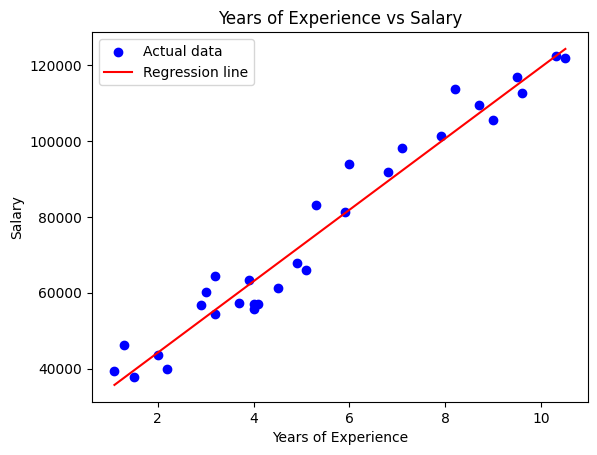

In [28]:
#illustrating the regression line
plt.scatter(feature, target, color='blue', label='Actual data')
plt.plot(feature, model.predict(feature), color='red', label='Regression line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Years of Experience vs Salary')
plt.legend()
plt.show()

8. Loss Function and Evaluation Metrics

* **Mean Squared Error** measures the squared difference between the estimated values and the actual values.

* **R2 Score** measures the proportion of variance in the variable that is predictable from the independent variable.


In [29]:
#Loss function selection and optimization
y_pred = model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse:,.2f}')
print(f'R² Score          : {r2:.4f}')

Mean Squared Error: 49,830,096.86
R² Score          : 0.9024


9. Model Interpretation

* **Model.coef_** represents the slope, how much the target changes for every single-unit increase, in the feature.

* **model.intercept_** represents the point where the regression line crosses the y-axis the predicted value of the target when the feature equals zero.

In [30]:
#model evaluation and interpretation
print(f'Coefficients: {model.coef_}')
print(f'Intercept: {model.intercept_}')

#here coefficients represents the change in salary for each increase in year of experience
# here intercept represents the estimated salary when years of experience is zero

Coefficients: [[9423.81532303]]
Intercept: [25321.58301178]
